### Universal Approximation Theorem (intuition)

### Empirical Demonstration (3D Surface)

---

#### Step 1 — Define a Continuous Target Function (Ground Truth Surface)

To build an empirical intuition for the Universal Approximation Theorem, we begin by defining a continuous nonlinear function that will act as our ground truth surface.

We choose:

$$
f(x_1, x_2) = \sin(x_1)\cos(x_2)
$$

This function satisfies the key assumptions of the theorem:
- It is continuous
- It is nonlinear
- It is smooth over the domain
- It cannot be represented by a single affine transformation

From a geometric perspective, this function produces a curved surface in the input space, making it an ideal candidate for testing the approximation capacity of a Multilayer Perceptron (MLP).

---

#### Step 2 — Dataset Construction on a Compact Domain

The Universal Approximation Theorem is stated for continuous functions defined on compact sets.  
Intuitively, a compact domain is a bounded and closed region of the input space.

In this experiment, we restrict the inputs to:

$$
(x_1, x_2) \in [-\pi, \pi] \times [-\pi, \pi]
$$

This bounded region represents a compact subset of $\mathbb{R}^2$, which aligns with the theoretical assumptions of the theorem and with practical machine learning settings where inputs live in finite ranges.

We will:
- Sample training points within this domain
- Compute targets using the true function
- Use a dense meshgrid for surface visualization

---


In [28]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.typing import ArrayLike

rng = np.random.default_rng(42)

def func(x: ArrayLike) -> ArrayLike:
    return np.sin(x[:, 0]) * np.cos(x[:, 1])

n_samples = 1000

X = rng.uniform(-np.pi, np.pi, size=(n_samples, 2))
y = func(X).reshape(-1, 1)

#### Step 3 — Baseline Model: Linear (Affine) Surface

Before introducing neural networks, we establish a baseline using a linear model:

$$
\hat{y} = w_1 x_1 + w_2 x_2 + b
$$

This model represents an affine transformation of the input space.  
Geometrically, it produces a plane.

Since the target function is nonlinear, we expect:
- Strong underfitting
- High approximation error
- An inability to capture the curvature of the true surface

This step reinforces a key concept studied previously: affine maps cannot approximate complex nonlinear functions.

In [27]:
def linear_model(X: ArrayLike, w: ArrayLike, b: float) -> ArrayLike:
    return X @ w + b

def mse_loss(y_true: ArrayLike, y_pred: ArrayLike) -> float:
    return np.mean((y_true - y_pred) ** 2)

def compute_linear_gradients(X: ArrayLike, y: ArrayLike, y_pred: ArrayLike):
    n = X.shape[0]    
    error = (y_pred - y) 
    
    dw = (2 / n) * (X.T @ error)
    db = (2 / n) * np.sum(error)
    return dw, db

def train_linear_model(
    X: ArrayLike,
    y: ArrayLike,
    epochs: int = 500,
    learning_rate: float = 0.01,
    verbose: bool = True
):
    
    b = 0.0
    loss_history = []
    w = rng.normal(0, 0.1, size=(2, 1))


    for epoch in range(epochs):
        
        # Forward pass
        y_pred = linear_model(X, w, b)
        
        # Compute loss (MSE)
        loss = mse_loss(y, y_pred)
        loss_history.append(loss)
        
        # Gradients (analytical)
        dw, db = compute_linear_gradients(X, y, y_pred)
        
        # Parameter update (Gradient Descent)
        w -= learning_rate * dw
        b -= learning_rate * db
        
        # Optional logging
        if verbose and epoch % 50 == 0:
            print(f"Epoch {epoch} | Loss: {loss:.6f}")
    
    return w, b, loss_history

w, b, loss_history = train_linear_model(X, y)
y_pred = linear_model(X, w, b)

Epoch 0 | Loss: 0.402093
Epoch 50 | Loss: 0.251623
Epoch 100 | Loss: 0.251431
Epoch 150 | Loss: 0.251431
Epoch 200 | Loss: 0.251431
Epoch 250 | Loss: 0.251431
Epoch 300 | Loss: 0.251431
Epoch 350 | Loss: 0.251431
Epoch 400 | Loss: 0.251431
Epoch 450 | Loss: 0.251431


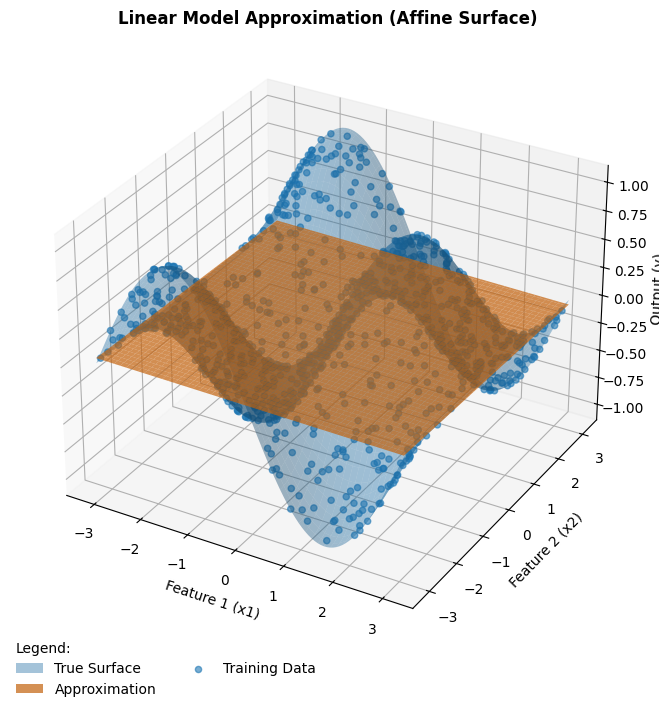

In [37]:
batch_size = 100

x1_grid, x2_grid = np.meshgrid(
    np.linspace(-np.pi, np.pi, batch_size),
    np.linspace(-np.pi, np.pi, batch_size)
)

X_grid = np.column_stack([
    x1_grid.ravel(),
    x2_grid.ravel()
])

z_linear = linear_model(X_grid, w, b)
z_linear_surface = z_linear.reshape(x1_grid.shape)

z_true = func(X_grid).reshape(x1_grid.shape)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(x1_grid, x2_grid, z_true, alpha=0.4, label='True Surface')
ax.plot_surface(x1_grid, x2_grid, z_linear_surface, alpha=0.7, label='Approximation')
ax.scatter(X[:, 0], X[:, 1], y.flatten(), alpha=0.6, label="Training Data")

ax.set_title("Linear Model Approximation (Affine Surface)", fontweight="bold")
ax.set_xlabel("Feature 1 (x1)")
ax.set_ylabel("Feature 2 (x2)")
ax.set_zlabel("Output (y)")

ax.legend(bbox_to_anchor=(.5, -.1), ncol=2, title='Legend:', frameon=False, loc='lower right', alignment='left')
plt.show()

#### Step 4 — Multilayer Perceptron as a Nonlinear Function Approximator

We then introduce a one-hidden-layer Multilayer Perceptron (MLP), defined as:

$$
z_1 = X W_1 + b_1
$$

$$
a_1 = \phi(z_1)
$$

$$
\hat{y} = a_1 W_2 + b_2
$$

Where:
- $z_1$ is the affine transformation of the inputs
- $\phi(\cdot)$ is a nonlinear activation function
- $a_1$ is the hidden representation
- $\hat{y}$ is the predicted output

Unlike a linear model, the presence of the activation function allows the network to learn nonlinear mappings and produce curved surfaces in the feature space.

In [54]:
def relu(z: ArrayLike) -> ArrayLike:
    return np.maximum(0, z)

def relu_derivative(z: ArrayLike) -> ArrayLike:
    return (z > 0).astype(float)

def init_mlp_params(input_dim: int, hidden_dim: int, rng):
    W1 = rng.normal(0, 0.1, size=(input_dim, hidden_dim))
    b1 = np.zeros((1, hidden_dim))
    
    W2 = rng.normal(0, 0.1, size=(hidden_dim, 1))
    b2 = np.zeros((1, 1))
    
    return W1, b1, W2, b2

def mlp_forward(X: ArrayLike, W1: ArrayLike, b1: ArrayLike, W2: ArrayLike, b2: ArrayLike):
    z1 = X @ W1 + b1        
    a1 = relu(z1)          
    y_pred = a1 @ W2 + b2  
    
    cache = (X, z1, a1)  # stored for backpropagation
    return y_pred, cache

def mlp_backward(y_true, y_pred, cache, W2):
    X, z1, a1 = cache
    n = X.shape[0]
    
    error = (y_pred - y_true)
    dW2 = (2 / n) * (a1.T @ error)   
    db2 = (2 / n) * np.sum(error, axis=0, keepdims=True)
    
    da1 = error @ W2.T              
    dz1 = da1 * relu_derivative(z1)    
    
    dW1 = (2 / n) * (X.T @ dz1)        
    db1 = (2 / n) * np.sum(dz1, axis=0, keepdims=True)  
    return dW1, db1, dW2, db2

def train_mlp(
    X: ArrayLike,
    y: ArrayLike,
    hidden_dim: int = 10,
    epochs: int = 500,
    learning_rate: float = 0.01,
    verbose: bool = True
):
    
    input_dim = X.shape[1]
    W1, b1, W2, b2 = init_mlp_params(input_dim, hidden_dim, rng)
    
    loss_history = []
    
    for epoch in range(epochs):
        
        # Forward pass
        y_pred, cache = mlp_forward(X, W1, b1, W2, b2)
        
        # Loss (MSE)
        loss = np.mean((y - y_pred) ** 2)
        loss_history.append(loss)
        
        # Backpropagation
        dW1, db1, dW2, db2 = mlp_backward(y, y_pred, cache, W2)
        
        # Parameter updates
        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1
        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2
        
        if verbose and epoch % 50 == 0:
            print(f"Epoch {epoch} | Loss: {loss:.6f}")
    
    return W1, b1, W2, b2, loss_history

W1, b1, W2, b2, loss_history = train_mlp(X, y)

Epoch 0 | Loss: 0.255990
Epoch 50 | Loss: 0.253478
Epoch 100 | Loss: 0.252438
Epoch 150 | Loss: 0.251670
Epoch 200 | Loss: 0.250999
Epoch 250 | Loss: 0.250353
Epoch 300 | Loss: 0.249699
Epoch 350 | Loss: 0.249013
Epoch 400 | Loss: 0.248250
Epoch 450 | Loss: 0.247399


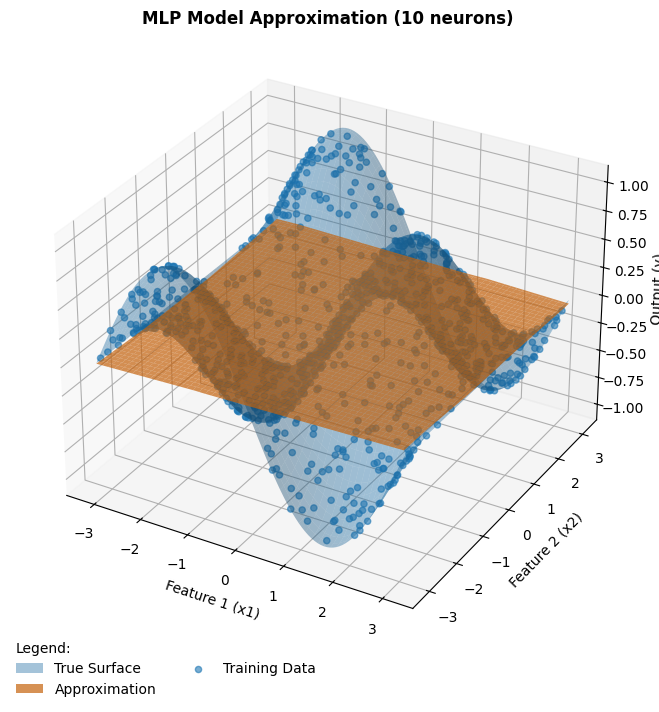

In [55]:
pred, cache = mlp_forward(X_grid, W1, b1, W2, b2)
mlp_surface = pred.reshape(x1_grid.shape)

z_true = func(X_grid).reshape(x1_grid.shape)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(x1_grid, x2_grid, z_true, alpha=0.4, label='True Surface')
ax.plot_surface(x1_grid, x2_grid, mlp_surface, alpha=0.7, label='Approximation')
ax.scatter(X[:, 0], X[:, 1], y.flatten(), alpha=0.6, label="Training Data")

ax.set_title("MLP Model Approximation (10 neurons)", fontweight="bold")
ax.set_xlabel("Feature 1 (x1)")
ax.set_ylabel("Feature 2 (x2)")
ax.set_zlabel("Output (y)")

ax.legend(bbox_to_anchor=(.5, -.1), ncol=2, title='Legend:', frameon=False, loc='lower right', alignment='left')
plt.show()

Epoch 0 | Loss: 0.387481
Epoch 50 | Loss: 0.204402
Epoch 100 | Loss: 0.163478
Epoch 150 | Loss: 0.132112
Epoch 200 | Loss: 0.108077
Epoch 250 | Loss: 0.089502
Epoch 300 | Loss: 0.075155
Epoch 350 | Loss: 0.064051
Epoch 400 | Loss: 0.055305
Epoch 450 | Loss: 0.048325


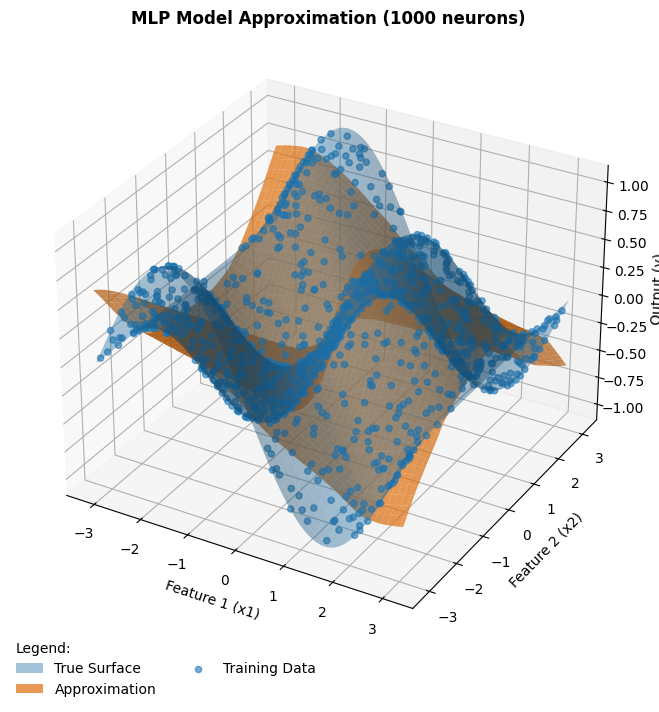

In [56]:
W1, b1, W2, b2, loss_history = train_mlp(X, y, hidden_dim=1000)
pred, cache = mlp_forward(X_grid, W1, b1, W2, b2)
mlp_surface = pred.reshape(x1_grid.shape)

z_true = func(X_grid).reshape(x1_grid.shape)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(x1_grid, x2_grid, z_true, alpha=0.4, label='True Surface')
ax.plot_surface(x1_grid, x2_grid, mlp_surface, alpha=0.7, label='Approximation')
ax.scatter(X[:, 0], X[:, 1], y.flatten(), alpha=0.6, label="Training Data")

ax.set_title("MLP Model Approximation (1000 neurons)", fontweight="bold")
ax.set_xlabel("Feature 1 (x1)")
ax.set_ylabel("Feature 2 (x2)")
ax.set_zlabel("Output (y)")

ax.legend(bbox_to_anchor=(.5, -.1), ncol=2, title='Legend:', frameon=False, loc='lower right', alignment='left')
plt.show()

Epoch 0 | Loss: 8.297518
Epoch 50 | Loss: 0.247391
Epoch 100 | Loss: 0.169495
Epoch 150 | Loss: 0.131207
Epoch 200 | Loss: 0.108057
Epoch 250 | Loss: 0.092265
Epoch 300 | Loss: 0.080505
Epoch 350 | Loss: 0.071307
Epoch 400 | Loss: 0.063818
Epoch 450 | Loss: 0.057633


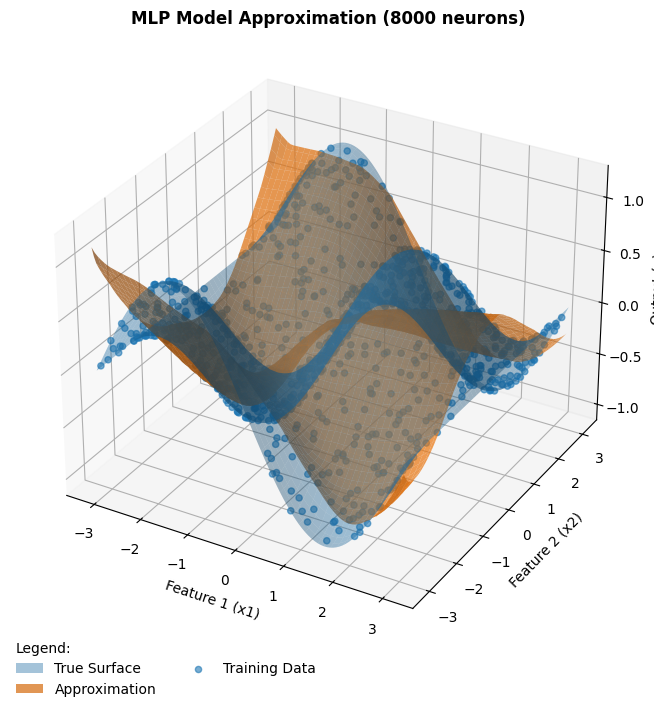

In [57]:
W1, b1, W2, b2, loss_history = train_mlp(X, y, hidden_dim=8000)
pred, cache = mlp_forward(X_grid, W1, b1, W2, b2)
mlp_surface = pred.reshape(x1_grid.shape)

z_true = func(X_grid).reshape(x1_grid.shape)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(x1_grid, x2_grid, z_true, alpha=0.4, label='True Surface')
ax.plot_surface(x1_grid, x2_grid, mlp_surface, alpha=0.7, label='Approximation')
ax.scatter(X[:, 0], X[:, 1], y.flatten(), alpha=0.6, label="Training Data")

ax.set_title("MLP Model Approximation (8000 neurons)", fontweight="bold")
ax.set_xlabel("Feature 1 (x1)")
ax.set_ylabel("Feature 2 (x2)")
ax.set_zlabel("Output (y)")

ax.legend(bbox_to_anchor=(.5, -.1), ncol=2, title='Legend:', frameon=False, loc='lower right', alignment='left')
plt.show()

As we increase the number of hidden neurons from 10 to 1000 and then to 8000, we observe a clear improvement in the model’s ability to approximate the target function. With a small hidden layer (e.g., 10 neurons), the MLP has limited representational capacity, resulting in a rough and underfit surface that captures only the broad structure of the function. As the width increases to 1000 neurons, the network gains a richer set of nonlinear basis functions, allowing it to model finer variations and produce a significantly smoother and more accurate surface. When expanded further to 8000 neurons, the model’s function space becomes even more expressive, enabling it to closely match the curvature and local patterns of the true function across the compact domain. This progressive improvement illustrates the core intuition behind the Universal Approximation Theorem: increasing the number of hidden units expands the set of functions the MLP can represent, allowing it to approximate continuous target functions with arbitrarily high precision, provided sufficient capacity and proper optimization.

Interestingly, the experiment with 1000 hidden neurons achieved a lower final loss than the model with 8000 neurons. At first glance, this may seem to contradict the intuition that increasing model capacity should always lead to better approximation. However, this result actually illustrates an important limitation of the Universal Approximation Theorem.

The theorem guarantees representational capacity, not optimization performance. In other words, it states that a sufficiently wide neural network can approximate any continuous function on a compact domain, but it does not guarantee that gradient descent will successfully find the optimal parameters in practice. As the number of neurons increases, the loss landscape becomes more complex, with more parameters, higher dimensional curvature, and potentially more unstable optimization dynamics.

In the case of the 8000-neuron model, the network has a much larger parameter space and a more intricate loss surface, which can make training harder rather than easier. Factors such as initialization, learning rate, and gradient flow become more influential as model width grows. As a result, even though the wider network has greater theoretical expressive power, it may converge more slowly or settle in a suboptimal region of the loss landscape.